In [ ]:
import os
import cv2
import librosa
import numpy as np
import random
from predictor import multimodal_predict
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

AUDIO_DIR = r"C:\Users\User\.cache\kagglehub\datasets\uwrfkaggler\ravdess-emotional-speech-audio\versions\1"
VIDEO_DIR = r"C:\Users\User\.cache\kagglehub\datasets\msambare\fer2013\versions\1\test"

rav_to_fer_idx = {1:6, 2:6, 3:3, 4:4, 5:0, 6:2, 7:1, 8:5}
fer_folder_map = {1:'neutral', 2:'neutral', 3:'happy', 4:'sad', 5:'angry', 6:'fear', 7:'disgust', 8:'surprise'}
y_true, y_pred = [], []
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
print("🚀 Starting ZenithView Multimodal Evaluation...")

for root, _, files in os.walk(AUDIO_DIR):
    for file in [f for f in files if f.endswith(".wav")]:
        try:
            parts = file.split('-')
            emotion_id = int(parts[2])
            audio_path = os.path.join(root, file)
            y, sr = librosa.load(audio_path, duration=2.5)
            mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
            a_feat = np.mean(mfcc.T, axis=0)
            emo_folder = fer_folder_map[emotion_id]
            img_list = os.listdir(os.path.join(VIDEO_DIR, emo_folder))
            img_path = os.path.join(VIDEO_DIR, emo_folder, random.choice(img_list))
            
            frame = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            resized = cv2.resize(frame, (48, 48))
            v_feat = clahe.apply(resized).astype('float32') / 255.0 # Shape (48, 48)

            res_str, conf = multimodal_predict(a_feat, v_feat)
            inv_map = {'Angry': 0, 'Disgust': 1, 'Fear': 2, 'Happy': 3, 'Sad': 4, 'Surprise': 5, 'Neutral': 6}
            y_pred.append(inv_map[res_str])
            y_true.append(rav_to_fer_idx[emotion_id])

        except Exception as e:
            print(f"⚠️ Error processing {file}: {e}")
if y_true:
    acc = accuracy_score(y_true, y_pred)
    print(f"\n✅ FINAL MULTIMODAL ACCURACY: {acc * 100:.2f}%")
   

🚀 Starting ZenithView Multimodal Evaluation...

✅ FINAL MULTIMODAL ACCURACY: 75.62%


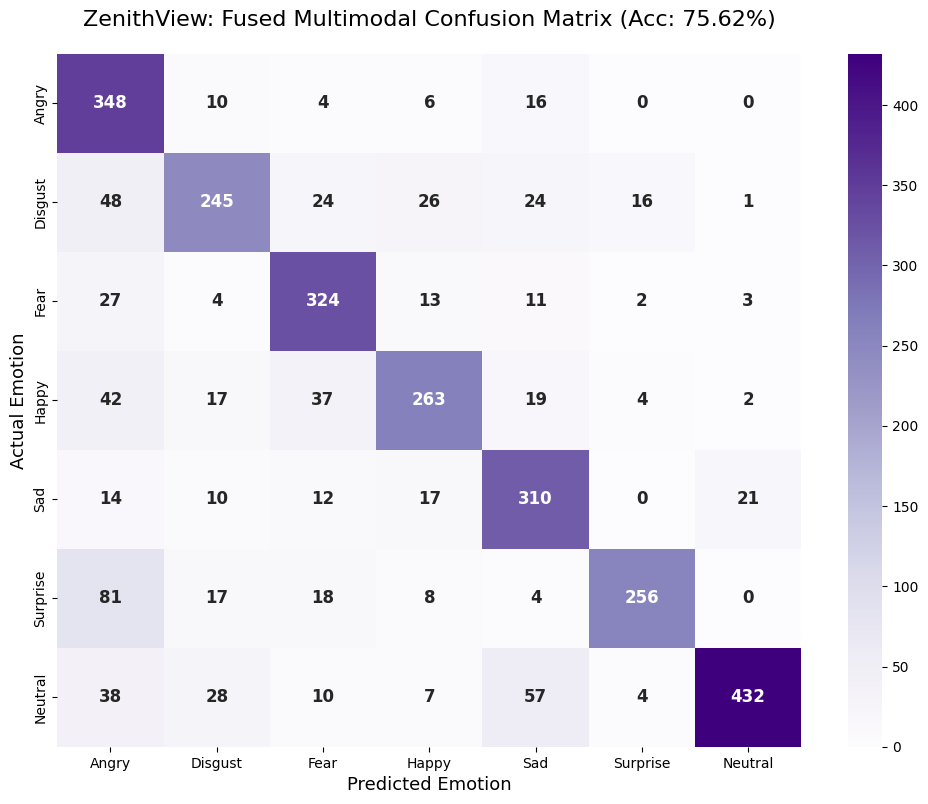

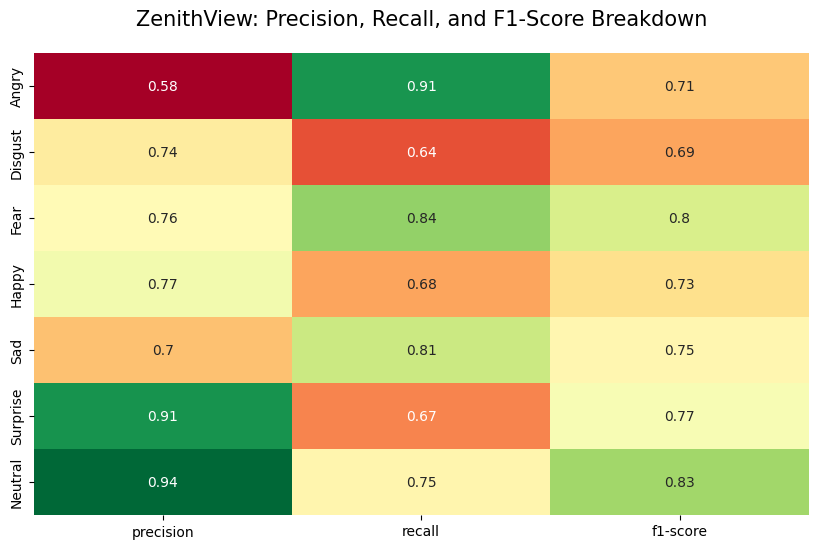


FINAL REPORT SUMMARY
              precision    recall  f1-score   support

       Angry       0.58      0.91      0.71       384
     Disgust       0.74      0.64      0.69       384
        Fear       0.76      0.84      0.80       384
       Happy       0.77      0.68      0.73       384
         Sad       0.70      0.81      0.75       384
    Surprise       0.91      0.67      0.77       384
     Neutral       0.94      0.75      0.83       576

    accuracy                           0.76      2880
   macro avg       0.77      0.76      0.75      2880
weighted avg       0.78      0.76      0.76      2880



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
plt.figure(figsize=(12, 9))
cm = confusion_matrix(y_true, y_pred)
target_names = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=target_names, 
            yticklabels=target_names,
            annot_kws={"size": 12, "weight": "bold"})

plt.title('ZenithView: Fused Multimodal Confusion Matrix (Acc: 75.62%)', fontsize=16, pad=20)
plt.ylabel('Actual Emotion', fontsize=13)
plt.xlabel('Predicted Emotion', fontsize=13)
plt.show()

report = classification_report(y_true, y_pred, target_names=target_names, output_dict=True)
report_df = pd.DataFrame(report).iloc[:-1, :7].T # Exclude support and averages for the map

plt.figure(figsize=(10, 6))
sns.heatmap(report_df, annot=True, cmap='RdYlGn', cbar=False)
plt.title('ZenithView: Precision, Recall, and F1-Score Breakdown', fontsize=15, pad=20)
plt.show()

# --- 3. PRINT SUMMARY STATISTICS ---
print("\n" + "="*30)
print("FINAL REPORT SUMMARY")
print("="*30)
print(classification_report(y_true, y_pred, target_names=target_names))